# Notebook 3 — Quantifying uncertainty (common)

*Day 5a · everyone turns predictions into intervals, then asks whether they're honest — before forking to a model-native uncertainty lab.*

In [1]:
# ======================================================================================
# Setup — run this first (you don't need to read it closely).
# It imports a few libraries, sets a shared plot style, and defines the helper functions used
# throughout the notebook (load_data, the plot helpers, the metric helpers, ...).  These are the
# SAME helpers in every notebook, so your results line up with your teammates'.  If a later cell
# says a helper is "not defined", you probably skipped this cell — run it, then carry on.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------
# Paths — resolved so the notebooks work whether they're run from the materials folder or
# from solutions/ .  Outputs and figures always land in the materials root.
# ----------------------------------------------------------------------------------------
def _materials_root():
    """Folder that contains data/ ; searched upward from the working directory."""
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "data")):
            return d
    return here

ROOT = _materials_root()
DATA_DIR = os.path.join(ROOT, "data")
OUTPUTS_DIR = os.path.join(ROOT, "outputs")
FIGURES_DIR = os.path.join(ROOT, "figures")
MODELS_DIR = os.path.join(ROOT, "models")     # fitted models saved to disk (experiment tracking)
for _d in (DATA_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR):
    os.makedirs(_d, exist_ok=True)

# Module-level cache of the reconstruction basis (set by load_data; used by reconstruct_spectrum).
_RECON = {"wavelength": None, "basis": None, "is_mock": True, "Xerr": None}
_RAW_CACHE = {}   # path -> full arrays, so repeated load_data() calls don't re-read the file

# Default working-set size.  The real catalog is ~263k stars; we train on a fast deterministic
# subsample by default so in-class fits stay quick AND every notebook sees the SAME stars (which
# keeps the NB2->NB3->NB4 saved-prediction hand-off aligned).  Pass n=None to use the WHOLE
# high-quality catalog (the "does more data help?" / label-transfer-at-scale exercise).
DEFAULT_N = 30000

# Canonical label columns.  The modelling track predicts [Fe/H]; Teff & logg are explored and
# used as the axes for residual / coverage maps.  alpha/age/dist are extra "explore" labels.
LABEL_COLS = ["Teff", "logg", "FeH", "alpha", "age", "dist"]
PRETTY = {"Teff": r"$T_\mathrm{eff}$ [K]", "logg": r"$\log g$ [dex]",
          "FeH": r"[Fe/H] [dex]", "alpha": r"[$\alpha$/M] [dex]",
          "age": "age [Gyr]", "dist": "distance [pc]"}


# ========================================================================================
# Plot style
# ========================================================================================
def set_plot_style():
    """Consistent, readable matplotlib defaults.  Called once in setup."""
    plt.rcParams.update({
        "figure.figsize": (6.4, 4.4), "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "font.size": 12, "axes.titlesize": 13,
        "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.25,
        "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 11, "lines.linewidth": 2.0,
        "scatter.edgecolors": "none", "image.cmap": "viridis",
    })

# A small colour-blind-friendly palette used across the materials for named series.
COLORS = {"linear": "#888888", "knn": "#0072B2", "rf": "#009E73",
          "nn": "#D55E00", "native": "#0072B2", "conformal": "#D55E00",
          "truth": "#222222", "accent": "#CC79A7"}


# ========================================================================================
# Data loading  (the mock generator lives here so the shipped npz and the on-the-fly
# fallback are guaranteed identical)
# ========================================================================================
_C2_NM = 1.438777e7  # second radiation constant hc/k in nm*K


def _build_basis(wave_min=336.0, wave_max=1020.0, n_wave=343, n_bp=55, n_rp=55):
    """Smooth windowed-cosine modes per band, orthonormalised.  Low modes are broad
    (continuum), high modes wiggly (fine structure).  reconstruct = B @ coeff."""
    wave = np.linspace(wave_min, wave_max, n_wave)
    cols = []
    def band(lo, hi, n_modes):
        x = (wave - lo) / (hi - lo)
        win = np.where((x >= 0) & (x <= 1), np.sin(np.clip(x, 0, 1) * np.pi) ** 0.5, 0.0)
        for j in range(n_modes):
            cols.append(np.cos(j * np.pi * np.clip(x, 0, 1)) * win)
    band(wave_min, 690.0, n_bp)
    band(630.0, wave_max, n_rp)
    Q, _ = np.linalg.qr(np.column_stack(cols))
    return wave, Q[:, :n_bp + n_rp]


def _synthesize_mock(n=50000, seed=42):
    """
    # MOCK DATA — swap for the real Zenodo loader.
    Physically-motivated synthetic stand-in for the Laroche & Speagle APOGEE x Gaia-XP
    cross-match.  Returns the same dict that the shipped npz stores.  See the build spec
    and _build/make_mock_dataset.py for the full rationale.  In one sentence: a Planck
    continuum sets Teff; Balmer lines reinforce Teff; gravity-sensitive molecular bands
    carry log g; SHALLOW metal lines (suppressed at high Teff) carry the hard, heteroscedastic
    [Fe/H]; reddening + hidden factors add a realistic irreducible (aleatoric) floor.
    """
    rng = np.random.default_rng(seed)
    wave, B = _build_basis()
    W = wave.size

    # --- labels with Kiel-diagram structure: dwarfs + giants + red clump + metal-poor halo ---
    is_giant = rng.random(n) < 0.45
    Teff = np.empty(n); logg = np.empty(n); FeH = np.empty(n)
    nd, ng = np.count_nonzero(~is_giant), np.count_nonzero(is_giant)
    Td = 4000 + 3100 * rng.beta(1.5, 2.5, nd)
    Teff[~is_giant] = Td
    logg[~is_giant] = 4.62 - 0.00013 * (Td - 4500) + rng.normal(0, 0.10, nd)
    FeH[~is_giant] = rng.normal(-0.05, 0.25, nd)
    Tg = 3800 + 1700 * rng.beta(2.0, 2.3, ng)
    Teff[is_giant] = Tg
    logg[is_giant] = 1.7 + 0.00095 * (Tg - 3800) + rng.normal(0, 0.33, ng)
    FeH[is_giant] = rng.normal(-0.28, 0.34, ng)
    clump = is_giant & (rng.random(n) < 0.33); nc = np.count_nonzero(clump)
    Teff[clump] = rng.normal(4800, 140, nc); logg[clump] = rng.normal(2.45, 0.11, nc)
    FeH[clump] = rng.normal(-0.10, 0.20, nc)
    halo = rng.random(n) < 0.06; nh = np.count_nonzero(halo)
    Teff[halo] = rng.normal(4900, 450, nh)
    logg[halo] = np.clip(rng.normal(2.2, 0.7, nh), 0.5, 3.6)
    FeH[halo] = rng.normal(-1.45, 0.45, nh)
    is_giant = is_giant | halo
    Teff = np.clip(Teff, 3500, 7600); logg = np.clip(logg, 0.3, 5.0); FeH = np.clip(FeH, -2.4, 0.55)
    alpha = np.clip(0.13 - 0.24 * FeH + rng.normal(0, 0.035, n), -0.05, 0.5)
    age = np.clip(2.0 + 6.5 * is_giant - 3.5 * FeH + rng.normal(0, 1.8, n), 0.3, 13.5)
    dist = np.exp(rng.normal(6.7, 0.9, n)) * (1.0 + 1.5 * is_giant)

    # --- forward model: labels -> flux ---
    def gauss(c, w): return np.exp(-0.5 * ((wave - c) / w) ** 2)
    x = _C2_NM / (wave[None, :] * Teff[:, None])
    flux = wave[None, :] ** -5 / np.expm1(np.clip(x, 1e-6, 700))
    flux = flux / flux.mean(axis=1, keepdims=True)
    jump = 1.0 / (1.0 + np.exp((wave - 382.0) / 6.0))
    flux *= 1.0 - (0.18 * np.clip((Teff - 5200) / 2500, 0, 1.4) * (1 + 0.15 * (4.5 - logg)))[:, None] * jump[None, :]
    balmer = sum(a * gauss(c, 9.0) for c, a in [(434., .9), (486.1, 1.1), (656.3, 1.)])
    bstr = np.clip(np.exp((Teff - 5200) / 1500), 0.15, 6.0) * (1 + 0.12 * (4.5 - logg))
    flux *= 1.0 - 0.012 * bstr[:, None] * balmer[None, :]
    g_dwarf = np.clip(logg - 3.0, 0, 2.0)[:, None]; g_giant = np.clip(3.6 - logg, 0, 3.2)[:, None]
    coolf = np.clip((5500 - Teff) / 2000.0, 0.2, 1.4)[:, None]
    grav = np.zeros((n, W))
    for c, a in [(488., 1.), (521., .9), (692., .8)]: grav += a * g_dwarf * gauss(c, 15.)[None, :]
    for c, a in [(421., .9), (793., .8), (883., 1.)]: grav += a * g_giant * gauss(c, 17.)[None, :]
    flux *= 1.0 - 0.038 * coolf * grav
    metal = sum(a * gauss(c, 11.0) for c, a in
                [(422.7, 1.), (460., .7), (517.3, 1.2), (527., .9), (589.3, 1.1),
                 (670.8, .6), (770., .6), (850., .8), (920., .5)])
    # Line depth scales with metal abundance (metal-poor stars have WEAK lines -> little [Fe/H]
    # information -> the dominant, physically-correct source of heteroscedastic [Fe/H] error).
    # Temperature only mildly suppresses lines; gravity gives luminous giants slightly weaker,
    # more variable lines (they are also the sparsest, most-extrapolated regime).
    mstr = 10.0 ** (0.55 * FeH)
    tsupp = np.clip(np.exp(-(Teff - 4500) / 4800.0), 0.6, 1.25)
    line_amp = (mstr * tsupp * np.clip(0.7 + 0.22 * logg, 0.7, 1.4))[:, None]
    flux *= 1.0 - 0.045 * line_amp * metal[None, :]
    ebv = np.abs(rng.normal(0, 0.11, n))[:, None]
    ext = (550.0 / wave) ** 1.0
    flux *= 10.0 ** (-0.4 * 1.6 * ebv * (ext / ext.mean())[None, :])
    P = np.column_stack([np.sin(f * np.pi * (wave - wave[0]) / (wave[-1] - wave[0])) for f in (1.5, 3.5, 6.5)])
    flux *= 1.0 + 0.004 * (rng.normal(0, 1, (n, 3)) @ P.T)
    gflux = np.exp(rng.normal(0.0, 0.8, n))
    snr = np.clip(58 * gflux ** 0.30 * np.exp(rng.normal(0, 0.30, n)), 20, 400)
    obs = gflux[:, None] * np.clip(flux, 1e-3, None)
    noise_std = obs.mean(axis=1, keepdims=True) / snr[:, None]        # photon-noise std (per star)
    obs = obs + rng.normal(0, 1, obs.shape) * noise_std
    X = (obs @ B).astype(np.float32)
    # per-coefficient measurement error on the RAW coefficients (the orthonormal basis preserves the
    # per-component noise std) — used by the NB3 input-Monte-Carlo stretch.
    Xerr = np.repeat(noise_std, 110, axis=1).astype(np.float32)
    return dict(X=X, Xerr=Xerr, Teff=Teff, logg=logg, FeH=FeH, alpha=alpha, age=age, dist=dist,
                snr=snr, gflux=gflux, source_id=(1_000_000_000 + np.arange(n)),
                wavelength=wave, basis=B.astype(np.float32), is_mock=True)


def load_data(path=None, n=DEFAULT_N, seed=0, verbose=True):
    """
    Load the dataset in one line:  X, y, meta = load_data()

    Parameters
    ----------
    n    : working-set size.  Returns a deterministic random subsample of `n` stars (default
           DEFAULT_N=30000) so fits are fast and every notebook sees the same stars.  Pass
           `n=None` to use the ENTIRE high-quality catalog (the scale-up exercise) — slower.
    seed : seed for the subsample (keep it fixed so the NB2->NB3->NB4 hand-off stays aligned).

    Returns
    -------
    X    : float array, shape (n, 110) — the Gaia XP coefficients (55 BP + 55 RP).
    y    : DataFrame with columns Teff, logg, FeH (+ alpha, dist) — the labels.
    meta : DataFrame with source_id, snr, gflux — per-star bookkeeping (gflux is the
           brightness scale used by normalize_by_g).
    """
    if path is None:
        for cand in ("xp_apogee_real.npz", "xp_apogee_mock.npz"):
            p = os.path.join(DATA_DIR, cand)
            if os.path.exists(p):
                path = p
                break
    key = path if path is not None else "__synth__"
    if key in _RAW_CACHE:
        data = _RAW_CACHE[key]
    elif path is not None and os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        data = {k: d[k] for k in d.files}
        _RAW_CACHE[key] = data
    else:
        if verbose:
            print("No data file found — synthesising the mock dataset on the fly.")
        data = _synthesize_mock()
        _RAW_CACHE[key] = data
    is_mock = bool(data.get("is_mock", True))
    src = os.path.basename(path) if path else "synthesised mock"

    _RECON["wavelength"] = np.asarray(data["wavelength"], float)
    _RECON["basis"] = np.asarray(data["basis"], float)
    _RECON["is_mock"] = is_mock

    X_all = np.asarray(data["X"], dtype=float)
    N = X_all.shape[0]
    if n is not None and n < N:
        sel = np.sort(np.random.default_rng(seed).permutation(N)[:n])
    else:
        sel = np.arange(N)
    X = X_all[sel]
    _RECON["Xerr"] = np.asarray(data["Xerr"], float)[sel] if "Xerr" in data else None  # for input-MC (NB3)
    y = pd.DataFrame({c: np.asarray(data[c], float)[sel] for c in LABEL_COLS if c in data})
    meta = pd.DataFrame({k: np.asarray(data[k]).ravel()[sel] for k in ("source_id", "snr", "gflux") if k in data})
    if verbose:
        tag = "MOCK (synthetic)" if is_mock else "REAL (Gaia XP x APOGEE)"
        extra = f" (subsampled from {N:,}; pass n=None for all)" if len(sel) < N else ""
        print(f"Loaded {src}: {tag}  —  {X.shape[0]:,} stars{extra}, {X.shape[1]} coefficients.")
    return X, y, meta


# ========================================================================================
# Spectrum reconstruction
# ========================================================================================
def load_input_errors():
    """Per-coefficient measurement errors for the stars from the LAST `load_data()` call (same rows,
    same order, same (n, 110) shape as the `X` you just loaded) — on the RAW coefficient scale.
    For the NB3 input-Monte-Carlo stretch:  X_perturbed = X + rng.normal(0, load_input_errors()).
    Returns None if the dataset has no stored errors (call `load_data()` first)."""
    if _RECON["Xerr"] is None:
        load_data(verbose=False)
    return _RECON["Xerr"]


def reconstruct_spectrum(coeffs):
    """
    Turn a star's 110 XP coefficients into a sampled spectrum: returns (wavelength_nm, flux).
    Accepts a single (110,) vector or an (M, 110) batch.

    On the shipped data this uses the stored smooth basis (B @ coeff) — no extra packages.

    # REAL DATA: with the genuine Gaia archive continuous representation you would instead
    # reconstruct with GaiaXPy, e.g.:
    #     from gaiaxpy import calibrate
    #     sampling = np.arange(336, 1021, 2.0)              # nm
    #     spectra, sampled_wl = calibrate(source_dataframe, sampling=sampling, save_file=False)
    # The stored basis is recovered from Zenodo's wavelength-space spectra at curation time
    # (see _build/prepare_real_data.py), so this helper stays identical for mock and real.
    """
    if _RECON["basis"] is None:
        load_data(verbose=False)
    B, wave = _RECON["basis"], _RECON["wavelength"]
    coeffs = np.asarray(coeffs, float)
    flux = coeffs @ B.T
    return wave, flux


# ========================================================================================
# Preprocessing recipe:  normalize by the G-band  ->  standardize (fit on train only)
# ========================================================================================
def normalize_by_g(X, g):
    """Divide each star's coefficients by its G-band brightness scale `g` (a column of meta).
    Removes brightness/distance and keeps the spectral SHAPE — what carries the labels."""
    g = np.asarray(g, float).reshape(-1, 1)
    return np.asarray(X, float) / g


def standardize(X_train, X_other):
    """Z-score the coefficients using statistics from the TRAINING set only, then apply the
    same shift/scale to another split.  Returns (X_train_scaled, X_other_scaled).
    (Equivalent to sklearn's StandardScaler fit on train; spelled out for clarity.)"""
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (X_train - mu) / sd, (X_other - mu) / sd


# ========================================================================================
# Splitting  (fixed seed so every student gets the same train / cal / test stars)
# ========================================================================================
def train_cal_test_split(X, y, seed=0, fracs=(0.6, 0.2, 0.2)):
    """Reproducible 60/20/20 split into train / calibration / test.
    Returns a dict with X_* arrays, y_* DataFrames, and idx_* index arrays.
    Calibration is held out for the uncertainty work in NB3/NB4."""
    X = np.asarray(X, float)
    y = y.reset_index(drop=True)
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_tr = int(fracs[0] * n); n_ca = int(fracs[1] * n)
    i_tr, i_ca, i_te = idx[:n_tr], idx[n_tr:n_tr + n_ca], idx[n_tr + n_ca:]
    return {
        "X_train": X[i_tr], "X_cal": X[i_ca], "X_test": X[i_te],
        "y_train": y.iloc[i_tr].reset_index(drop=True),
        "y_cal": y.iloc[i_ca].reset_index(drop=True),
        "y_test": y.iloc[i_te].reset_index(drop=True),
        "idx_train": i_tr, "idx_cal": i_ca, "idx_test": i_te,
    }


# ========================================================================================
# Models — the four estimators the students compare.  Defined ONCE here so NB2, NB3 and NB4
# build byte-identical models, which is what lets predictions and intervals line up across
# notebooks and across the three students.  Each is a Pipeline(StandardScaler + estimator),
# so you feed it the G-normalized coefficients and it standardizes internally (fit on train).
# ========================================================================================
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAMES = {"linear": "Linear regression (baseline)", "knn": "K-nearest neighbors",
               "rf": "Random forest", "nn": "Neural network (MLP)"}

def make_model(name, **overrides):
    """Canonical Pipeline(StandardScaler + estimator) for a model name in {linear,knn,rf,nn}.
    Pass overrides to tune one knob, e.g. make_model('knn', n_neighbors=20).  The step name for
    the estimator is its lowercased class name (e.g. 'kneighborsregressor') — handy in NB3 when
    you reach inside the fitted pipeline for a model-native uncertainty."""
    if name == "linear":
        est = LinearRegression(**overrides)
    elif name == "knn":
        est = KNeighborsRegressor(**{"n_neighbors": 12, **overrides})
    elif name == "rf":
        est = RandomForestRegressor(**{"n_estimators": 150, "min_samples_leaf": 3,
                                       "random_state": 0, "n_jobs": -1, **overrides})
    elif name == "nn":
        est = MLPRegressor(**{"hidden_layer_sizes": (64, 64), "alpha": 1e-3, "max_iter": 500,
                              "early_stopping": True, "random_state": 0, **overrides})
    else:
        raise ValueError(f"unknown model '{name}' (use one of {list(MODEL_NAMES)})")
    return make_pipeline(StandardScaler(), est)


# ========================================================================================
# Metrics
# ========================================================================================
def regression_metrics(y_true, y_pred):
    """Return a dict of RMSE, MAE, bias (mean signed error), and R^2."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2)) or 1.0
    return {"RMSE": float(np.sqrt(np.mean(err ** 2))), "MAE": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)), "R2": float(1.0 - ss_res / ss_tot)}


# ========================================================================================
# Plots — predictions & residuals
# ========================================================================================
def plot_pred_vs_true(y_true, y_pred, title=None, ax=None, color=None, label=None, units=""):
    """Scatter of predicted vs true with the 1:1 line and an RMSE annotation."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    if ax is None:
        _, ax = plt.subplots()
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    pad = 0.04 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1.3, zorder=1)
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=color or COLORS["rf"], label=label, zorder=2)
    m = regression_metrics(y_true, y_pred)
    ax.text(0.04, 0.96, f"RMSE = {m['RMSE']:.3g}{units}\nbias = {m['bias']:+.2g}{units}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.85))
    ax.set_xlabel(f"true{(' ' + units) if units else ''}")
    ax.set_ylabel(f"predicted{(' ' + units) if units else ''}")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    if label:
        ax.legend(loc="lower right")
    return ax


def plot_residuals(y_true, y_pred, feature=None, feature_name="value", ax=None, color=None):
    """Residuals (pred - true) vs the truth, or vs an external `feature` (e.g. Teff).
    A flat band around zero means well-behaved errors; trends/fans flag structure."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_pred - y_true
    xx = np.asarray(feature, float) if feature is not None else y_true
    xlabel = feature_name if feature is not None else "true value"
    if ax is None:
        _, ax = plt.subplots()
    ax.axhline(0.0, color="0.4", ls="--", lw=1.3, zorder=1)
    ax.scatter(xx, resid, s=8, alpha=0.35, color=color or COLORS["rf"], zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("residual (pred − true)")
    return ax


# ========================================================================================
# Uncertainty — coverage, reliability, comparison
# ========================================================================================
def empirical_coverage(y_true, lower, upper):
    """Fraction of true values that fall inside [lower, upper]."""
    y_true = np.asarray(y_true, float)
    return float(np.mean((y_true >= np.asarray(lower, float)) & (y_true <= np.asarray(upper, float))))


def plot_reliability(y_true, lower, upper, target=None, feature=None, feature_name="bin",
                     n_bins=8, ax=None, color=None, label=None):
    """
    'Are the error bars honest, everywhere?'  Bins the points (by an external `feature` such
    as Teff if given, else by the interval centre) and plots empirical coverage per bin against
    the `target` line.  Bars sitting below the target reveal where intervals under-cover.
    """
    y_true = np.asarray(y_true, float)
    lower = np.asarray(lower, float); upper = np.asarray(upper, float)
    inside = (y_true >= lower) & (y_true <= upper)
    xx = np.asarray(feature, float) if feature is not None else 0.5 * (lower + upper)
    if ax is None:
        _, ax = plt.subplots()
    edges = np.quantile(xx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers, cov = [], []
    for i in range(n_bins):
        m = (xx >= edges[i]) & (xx < edges[i + 1])
        if m.sum() >= 5:
            centers.append(xx[m].mean()); cov.append(inside[m].mean())
    ax.plot(centers, cov, "o-", color=color or COLORS["native"], label=label)
    if target is not None:
        ax.axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
    ax.set_xlabel(feature_name if feature is not None else "interval centre")
    ax.set_ylabel("empirical coverage")
    ax.set_ylim(0, 1.02)
    if target is not None or label:
        ax.legend(loc="lower center")
    return ax


def compare_intervals(y_true, intervals, target=None, ax=None):
    """
    Compare several named interval sets.  `intervals` maps name -> (lower, upper).
    Draws two bars per method — coverage and median width — and returns a tidy summary table.
    """
    y_true = np.asarray(y_true, float)
    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({"method": name, "coverage": empirical_coverage(y_true, lo, hi),
                     "median_width": float(np.median(np.asarray(hi, float) - np.asarray(lo, float)))})
    tbl = pd.DataFrame(rows).set_index("method")
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    names = list(tbl.index)
    cols = [COLORS.get(n.split()[0].lower(), COLORS["accent"]) for n in names]
    ax[0].bar(names, tbl["coverage"], color=cols)
    if target is not None:
        ax[0].axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
        ax[0].legend()
    ax[0].set_ylabel("empirical coverage"); ax[0].set_ylim(0, 1.02); ax[0].set_title("Coverage")
    ax[1].bar(names, tbl["median_width"], color=cols)
    ax[1].set_ylabel("median interval width"); ax[1].set_title("Sharpness (narrower is better)")
    for a in ax:
        a.tick_params(axis="x", rotation=20)
    return tbl


# ========================================================================================
# Small convenience used in worked examples
# ========================================================================================
def savefig(name, fig=None):
    """Save a figure into figures/ for reuse on the poster.  Returns the path."""
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt.gcf()).savefig(path)
    return path


def save_outputs(filename, **arrays):
    """Save named arrays into outputs/<filename> (the shared NB2->NB3->NB4 contract)."""
    path = os.path.join(OUTPUTS_DIR, filename)
    np.savez(path, **arrays)
    return path


def load_outputs(filename):
    """Load an outputs/ npz written by an earlier notebook; returns a dict of arrays."""
    d = np.load(os.path.join(OUTPUTS_DIR, filename), allow_pickle=True)
    return {k: d[k] for k in d.files}


# ----- Experiment tracking: save fitted models + log runs (so you can reproduce & compare) -----
def save_model(model, name):
    """Save a fitted model/pipeline to models/<name>.joblib. Returns the path.
    The point: a tuned model is an experiment result — persist it so NB3 can load the exact model
    you tuned (no silent refit), and so you can reproduce a run weeks later."""
    import joblib
    path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(model, path)
    return path


def load_model(name):
    """Load a model previously saved with save_model(...)."""
    import joblib
    return joblib.load(os.path.join(MODELS_DIR, f"{name}.joblib"))


def log_experiment(name, params, metrics, filename=None):
    """Append one experiment run (its hyper-parameters + its metrics) to a CSV and return the full
    log as a DataFrame. This is the bare-bones version of what tools like MLflow / Weights & Biases
    do: a durable, comparable record of 'what did I try, and how did it score?'.
      params  : dict of hyper-parameters, e.g. {'n_neighbors': 12, 'weights': 'distance'}
      metrics : dict of scores, e.g. {'cv_rmse': 0.21, 'test_rmse': 0.20}
    """
    path = os.path.join(OUTPUTS_DIR, filename or f"{name}_experiments.csv")
    row = {"run": 1, **{f"param_{k}": v for k, v in params.items()}, **metrics}
    if os.path.exists(path):
        prev = pd.read_csv(path)
        row["run"] = int(prev["run"].max()) + 1 if "run" in prev else len(prev) + 1
        # Rebuild from records rather than pd.concat: a run that logs different params/metrics than
        # an earlier one would otherwise make pandas align mismatched columns into all-NA entries,
        # which raises a (noisy, harmless) FutureWarning.  Building one DataFrame from a list of
        # dicts fills the gaps with NaN silently and preserves column order.
        log = pd.DataFrame(prev.to_dict("records") + [row])
    else:
        log = pd.DataFrame([row])
    log.to_csv(path, index=False)
    return log

set_plot_style()
print('Setup complete — helpers ready.')


Setup complete — helpers ready.


## Welcome — from a prediction to an honest error bar

In Notebook 2 your team trained models that read a star's 110 Gaia XP numbers and predict its
metallicity **[Fe/H]**, and you saw the errors weren't uniform — they piled up on **metal-poor stars
and luminous giants**. A predicted number alone hides *how sure we are*. Today we put **honest error
bars** on those predictions.

This is the **common** notebook — everyone runs it together before splitting back to your own model.
The whole day is built around **doing, then naming**: you'll change a setting, watch a plot move, and
*then* we give the idea its name. Here's the arc:

1. **Why one number isn't enough** — and what an *interval* is.
2. **Run an experiment** that splits uncertainty into its two flavours (you'll *see* the split, not
   read a definition).
3. **Build a shared interval and probe it** — sweep its width, watch coverage move, and discover
   exactly where it lies to you.
4. **Fork** to your model's native-uncertainty lab (03a / 03b / 03c).

The rhythm, as always: **Explain → Worked (run it) → Your turn (change it, look again) → Explore (play).**

> Runs top-to-bottom as shipped. Every "your turn" cell already works — the task is to *change* a
> marked value and re-run. If a cell errors, grab a TA.

The honesty gap you'll uncover at the end is exactly what **Notebook 4** (conformal prediction) sets
out to fix — and where it still strains.

## 0 · Load the shared linear baseline's predictions

Everyone has the **linear baseline** from Notebook 2 — it's the common starting point, so we build
today's shared ideas on it. (Your own tuned model comes back in the *next* notebook, 03a/03b/03c.)

Notebook 2 saved the baseline's predictions to `outputs/linear_preds.npz` with four arrays:

| key | meaning |
|---|---|
| `y_cal_true`, `y_cal_pred` | truth & prediction on the **calibration** stars |
| `y_test_true`, `y_test_pred` | truth & prediction on the **test** stars |

One term to pin down now — the **calibration set**: the held-out chunk of stars that is *neither*
training *nor* test. Notebook 2 set it aside precisely so we could **check and size uncertainties**
here without cheating. Today is the day it earns its keep.

In [2]:
import warnings
from scipy.stats import norm

TARGET_LEVEL = 0.90                       # we want honest 90% intervals all day
k = norm.ppf((1 + TARGET_LEVEL) / 2)      # Gaussian multiplier: ~1.645 for 90% (a z-score)
print(f"target (nominal) coverage = {TARGET_LEVEL:.0%}    k = {k:.3f}")

# Notebook 2 (the common pipeline notebook) wrote this. load_outputs returns a dict of arrays.
try:
    base = load_outputs("linear_preds.npz")
except FileNotFoundError:
    raise FileNotFoundError(
        "Missing outputs/linear_preds.npz — run 02_pipeline_common first, then re-run this cell.")

print("keys:", list(base.keys()))
print(f"calibration stars: {base['y_cal_true'].size:,}    test stars: {base['y_test_true'].size:,}")

target (nominal) coverage = 90%    k = 1.645
keys: ['y_cal_true', 'y_cal_pred', 'y_test_true', 'y_test_pred']
calibration stars: 6,000    test stars: 6,000


## 1 · Why a single number isn't enough

A point prediction hides how confident the model is. "[Fe/H] = −0.30" could mean ±0.03 or ±0.30 —
those are *completely different scientific claims*. One says we've pinned the composition; the other
says we've barely constrained it. Science needs the **range**, not just the centre.

Three words we'll use all day:

- **Point estimate** — the single best-guess number (what Notebook 2 produced).
- **Prediction interval** — a range `[lower, upper]` meant to *contain* the true value.
- **Uncertainty** — the half-width of that interval, the "± part."

So the goal for today, in one sentence: **every prediction should come with an interval we can trust.**

But before we can build a trustworthy interval, it helps to know *where* the uncertainty even comes
from — because, as the next experiment shows, it comes in two very different flavours that you fix in
two very different ways.

*(For the formal version of "a 90% interval should contain the truth 90% of the time," see
Angelopoulos & Bates 2021, [arXiv:2107.07511](https://arxiv.org/abs/2107.07511), §1–2.)*

## 2 · An experiment: where does the error go as you add data?

Here's a question you can *answer with an experiment* instead of a definition. If we train the same
linear baseline on **more and more stars** and check its error on a held-out test set each time, what
happens to that error?

Two possibilities:
- it keeps **dropping toward zero** (with enough data the model becomes perfect), or
- it **drops, then flattens** onto a floor it can't get below.

Don't guess — **run it.** In the next cell you'll loop over growing dataset sizes, refit the linear
baseline each time (linear fits are instant, so this is quick), and plot **test error vs N**. Then
we'll read the answer straight off *your* curve.

  n =   1000  (train on   600)   test RMSE = 0.2256 dex
  n =   3000  (train on  1800)   test RMSE = 0.1975 dex
  n =  10000  (train on  6000)   test RMSE = 0.2012 dex
  n =  30000  (train on 18000)   test RMSE = 0.1981 dex


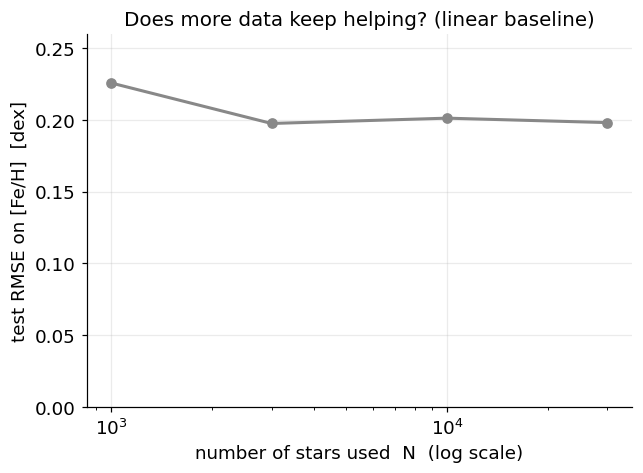


biggest -> smallest test RMSE: 0.226 -> 0.197 dex


In [3]:
from sklearn.metrics import root_mean_squared_error

# GOAL: refit the linear baseline on growing dataset sizes and record TEST error each time.
# load_data(n=...) returns a deterministic subsample of n stars; we then split + fit + score it.

sizes = [1000, 3000, 10000, 30000]   # <- your turn: add a small size like 500 at the front and re-run
test_rmse = []
for n in sizes:
    Xn_, yn_, mn_ = load_data(n=n, verbose=False)
    Xnorm = normalize_by_g(Xn_, mn_["gflux"])           # the recipe: brightness -> spectral shape
    spn   = train_cal_test_split(Xnorm, yn_, seed=0)    # same seed=0 split convention as everywhere
    lin   = make_model("linear").fit(spn["X_train"], spn["y_train"]["FeH"].to_numpy())
    rmse  = root_mean_squared_error(spn["y_test"]["FeH"].to_numpy(), lin.predict(spn["X_test"]))
    test_rmse.append(rmse)
    print(f"  n = {n:6d}  (train on {spn['X_train'].shape[0]:5d})   test RMSE = {rmse:.4f} dex")

test_rmse = np.array(test_rmse)

fig, ax = plt.subplots()
ax.plot(sizes, test_rmse, "o-", color=COLORS["linear"])
ax.set_xscale("log")
ax.set_xlabel("number of stars used  N  (log scale)")
ax.set_ylabel("test RMSE on [Fe/H]  [dex]")
ax.set_title("Does more data keep helping? (linear baseline)")
ax.set_ylim(0, max(test_rmse) * 1.15)
savefig("common_error_vs_N.png")
plt.show()
print(f"\nbiggest -> smallest test RMSE: {test_rmse.max():.3f} -> {test_rmse.min():.3f} dex")

### Now name what you saw: aleatoric vs epistemic

Your curve **dropped, then flattened** — and that shape *is* the whole idea. The error you measured is
really two things added together, and the experiment pulls them apart:

**Epistemic uncertainty** — *the model's own ignorance* (from Greek *epistēmē*, knowledge), from having
seen too few examples. This is the part that **shrank** as N grew: with more stars the model pins down
the input→[Fe/H] mapping better, especially in the sparse corners. It is large where training data is
thin (our **luminous giants** at low surface gravity `log g` sit in exactly such a sparse,
most-extrapolated corner) and small where data is dense. *The fix is more data.*

**Aleatoric uncertainty** — *irreducible noise in the data itself* (from Latin *alea*, dice). This is
the **floor** your curve flattened onto — the part more data **cannot** remove. Two sources: **photon
noise** (a telescope counts a finite, random number of photons, so every spectrum jitters), and, more
importantly here, **information that simply isn't there**. The features that reveal [Fe/H] are **weak
metal absorption lines** (small dips where metal atoms absorb light). In **metal-poor stars** those
lines are genuinely faint, so two stars with quite different [Fe/H] can produce nearly identical Gaia
spectra. *No model can undo this.*

When the aleatoric noise size *changes across the data* like this (small for metal-rich stars, large
for metal-poor ones), we call it **heteroscedastic** ("different scatter"); constant noise would be
**homoscedastic**. We'll *measure* this heteroscedasticity in §3.

**Why the distinction matters: the fix differs.** Aleatoric → honestly report a *wider* error bar.
Epistemic → *go get more data* from the under-sampled corners. Most simple methods hand you *one*
number blending the two; knowing which dominates tells you which lever to pull.

The real-science version: Laroche & Speagle (2025,
[arXiv:2404.07316](https://arxiv.org/abs/2404.07316)) found Gaia's chemical information is rich for
metal-rich disk stars and fades for the metal-poor, sparsely-sampled halo — the same failure we'll
keep meeting is the one real astronomers wrestle with. *(For a careful treatment of the two flavours,
see Hüllermeier & Waegeman 2021, [arXiv:1910.09457](https://arxiv.org/abs/1910.09457).)*

## 3 · Build a shared interval — then probe it until it breaks

Now we build the simplest honest interval everyone can make the same way, and then **stress-test it**
by changing things and watching what happens.

The idea: measure the **typical size of our mistakes** on held-out data, then draw the *same* ± band
around every prediction.

- A **residual** is `predicted − true` — the signed error on one star.
- Its **standard deviation σ** is a single number summarising "how far off we usually are."
- The interval is `prediction ± k·σ`, with `k ≈ 1.645` (the Gaussian multiplier that brackets the
  middle 90% of a bell curve).

> **⚠ Use the calibration set, not the training set.** The model already fit the training points, so
> its training residuals are optimistically small — they'd give dishonestly *narrow* intervals. The
> **calibration** stars are held out, so σ measured on them is honest. This is the single most
> important rule in the whole notebook.

Its built-in weakness, stated up front: **one width for every star** (it's homoscedastic). It *cannot*
widen for the genuinely harder stars. We're about to watch exactly that fail.

In [4]:
# 1) Residuals on the HELD-OUT calibration set (honest; the model never fit these).
resid_cal = base["y_cal_pred"] - base["y_cal_true"]      # signed errors, shape (n_cal,)
sigma = resid_cal.std()                                  # ONE number: typical [Fe/H] error (dex)
print(f"calibration residual scatter   sigma = {sigma:.3f} dex")
print(f"calibration bias (mean error)        = {resid_cal.mean():+.3f} dex   "
      f"(near 0 -> no systematic offset)")

# 2) The SAME +/- k*sigma band on every test star.
y_test_pred = base["y_test_pred"]
y_test_true = base["y_test_true"]
shared_lower = y_test_pred - k * sigma
shared_upper = y_test_pred + k * sigma
half_width = k * sigma
print(f"every interval has the SAME half-width = {half_width:.3f} dex   (one size fits all)")

# 3) Did it land at 90%?  empirical_coverage = fraction of TEST truths inside the band.
cov_shared = empirical_coverage(y_test_true, shared_lower, shared_upper)
print(f"\nshared interval: empirical coverage on test = {cov_shared:.1%}   (target = {TARGET_LEVEL:.0%})")

calibration residual scatter   sigma = 0.203 dex
calibration bias (mean error)        = -0.000 dex   (near 0 -> no systematic offset)
every interval has the SAME half-width = 0.334 dex   (one size fits all)

shared interval: empirical coverage on test = 94.5%   (target = 90%)


### Make it hit the target: sweep a fudge factor

Define **empirical coverage** = the fraction of test truths that actually fall inside the interval.
Define **nominal (target) coverage** = the level we *asked* for (here 0.90). An interval is
**calibrated** when empirical ≈ nominal.

> A "90% interval" is a statement about the **long-run fraction across many stars**, not a 90% chance
> for any single star.

Our band probably didn't land *exactly* on 90% — the Gaussian `k` is only approximately right. So
let's not trust the formula: let's **tune the width by hand** until coverage hits the target. We
multiply the half-width by a **fudge factor `c`** (so the band becomes `prediction ± c·k·σ`) and find
the `c` that makes coverage land on 90%.

**The honest way to do this:** pick `c` using the **calibration** set (truths we're allowed to peek
at), then *report* coverage on the untouched **test** set. Tuning the knob on test would be cheating —
you'd just be memorising the answer. This "tune on cal, report on test" move is the seed of conformal
prediction in Notebook 4.

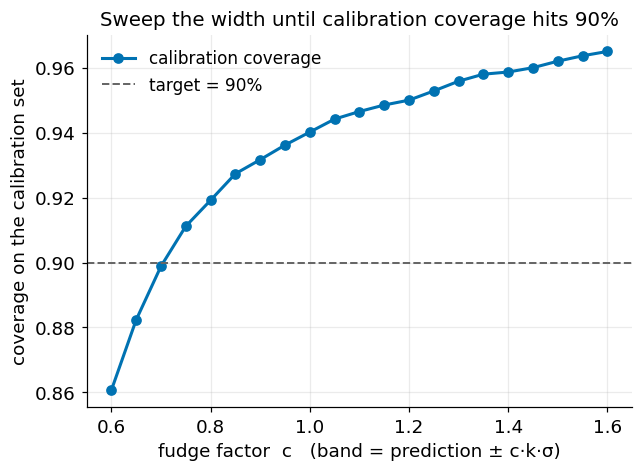

chosen c = 1.00
   calibration coverage at this c = 94.0%
   TEST coverage at this c        = 94.5%   (target = 90%)
   half-width: before = 0.334 dex   after = 0.334 dex


In [5]:
# Sweep the fudge factor c on the CALIBRATION set, then read coverage on test.
y_cal_pred = base["y_cal_pred"]; y_cal_true = base["y_cal_true"]

c_grid = np.linspace(0.6, 1.6, 21)
cal_cov = np.array([empirical_coverage(y_cal_true, y_cal_pred - c*k*sigma, y_cal_pred + c*k*sigma)
                    for c in c_grid])

fig, ax = plt.subplots()
ax.plot(c_grid, cal_cov, "o-", color=COLORS["native"], label="calibration coverage")
ax.axhline(TARGET_LEVEL, ls="--", color="0.4", lw=1.3, label=f"target = {TARGET_LEVEL:.0%}")
ax.set_xlabel("fudge factor  c   (band = prediction ± c·k·σ)")
ax.set_ylabel("coverage on the calibration set")
ax.set_title("Sweep the width until calibration coverage hits 90%")
ax.legend()
plt.show()

# Read off the c where the calibration curve crosses the target line, then set it here:
c_fudge = 1.0    # <- your turn: change this to the c that lands calibration coverage on 90% (try 0.85)

# Apply the SAME c to the TEST set and check coverage honestly.
shared_lower_c = y_test_pred - c_fudge * k * sigma
shared_upper_c = y_test_pred + c_fudge * k * sigma
cov_shared_c = empirical_coverage(y_test_true, shared_lower_c, shared_upper_c)
print(f"chosen c = {c_fudge:.2f}")
print(f"   calibration coverage at this c = "
      f"{empirical_coverage(y_cal_true, y_cal_pred - c_fudge*k*sigma, y_cal_pred + c_fudge*k*sigma):.1%}")
print(f"   TEST coverage at this c        = {cov_shared_c:.1%}   (target = {TARGET_LEVEL:.0%})")
print(f"   half-width: before = {k*sigma:.3f} dex   after = {c_fudge*k*sigma:.3f} dex")

### The catch: is it honest *everywhere*?

You just made marginal coverage hit 90%. But a single average can hide a lot. Let's **slice** the
coverage — bin the test stars and measure coverage *within each bin* — to see whether the (now
marginally-calibrated) interval is honest for every *kind* of star, or only on average.

We'll slice along two physical axes the constant interval is blind to:

- **surface gravity `log g`** — separates compact **dwarfs** (high `log g`, ≈ 4–5) from bloated,
  luminous **giants** (low `log g`, ≈ 1–3). Giants are the sparse, most-extrapolated stars.
- **metallicity `[Fe/H]`** — **metal-poor** stars (low `[Fe/H]`) have the faintest metal lines, so the
  least chemical information (that aleatoric floor again).

This is a **discovery** step. We don't know in advance which bins break — let the plots tell us. First
we reload the test labels; because Notebook 2 normalised *before* the seed=0 split, the saved
predictions line up row-for-row with a fresh split, so the labels match.

In [6]:
# Reload the labels for the SAME seed=0 split NB2 used (cheap; no model is fit here).
X, y, meta = load_data(verbose=False)
Xn = normalize_by_g(X, meta["gflux"])               # brightness -> spectral shape (the recipe)
sp = train_cal_test_split(Xn, y, seed=0)            # same split convention -> rows align with saved preds
logg_test = sp["y_test"]["logg"].to_numpy()
feh_test  = sp["y_test"]["FeH"].to_numpy()

# Tripwire: if these fire, the saved preds were built on a DIFFERENT split (fix NB2, don't relax this).
assert logg_test.size == y_test_true.size, "split mismatch: did NB2 normalize_by_g BEFORE the seed=0 split?"
assert np.allclose(sp["y_test"]["FeH"].to_numpy(), y_test_true), "row order mismatch with saved preds!"
print("labels aligned with saved predictions:", logg_test.size, "test stars")

labels aligned with saved predictions: 6000 test stars


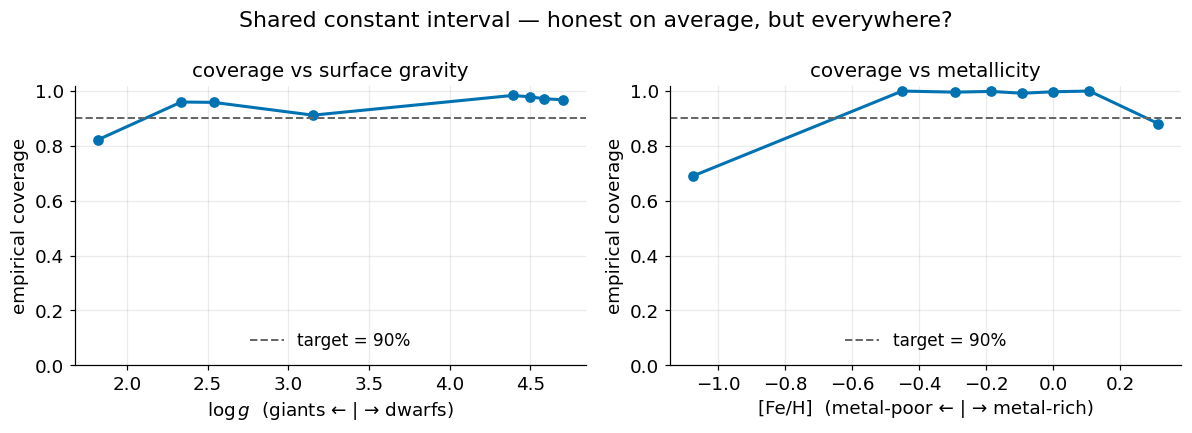

In [7]:
# Slice the FUDGED (marginally-calibrated) interval's coverage by both physical axes.
# plot_reliability bins the stars and shows coverage per bin against the target line.
lo_plot, hi_plot = shared_lower_c, shared_upper_c   # <- your turn: try shared_lower, shared_upper
                                                    #    (the UN-fudged band) and compare the sag

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_reliability(y_test_true, lo_plot, hi_plot, target=TARGET_LEVEL,
                 feature=logg_test, feature_name=r"$\log g$  (giants ← | → dwarfs)",
                 ax=axes[0])
axes[0].set_title("coverage vs surface gravity")
plot_reliability(y_test_true, lo_plot, hi_plot, target=TARGET_LEVEL,
                 feature=feh_test, feature_name=r"[Fe/H]  (metal-poor ← | → metal-rich)",
                 ax=axes[1])
axes[1].set_title("coverage vs metallicity")
fig.suptitle("Shared constant interval — honest on average, but everywhere?")
fig.tight_layout()
plt.show()
# <- look for: which bins sag BELOW the 90% line? The giants (low log g)? The metal-poor (low [Fe/H])?

**What we just found.** A fudge factor fixed the **marginal** (average) coverage — but conditionally
the interval is still **under-covering the luminous giants and the metal-poor stars**, and
**over-covering the metal-rich dwarfs**. One width can't be right everywhere when the true error isn't
constant (remember §2: the aleatoric floor is *heteroscedastic*).

This is the gap that drives the rest of the project:

- **Next (03a / 03b / 03c):** can *your* model build a **per-star** width out of its own internals —
  one that widens where the stars are genuinely hard?
- **Notebook 4:** can we *guarantee* a coverage level without trusting a Gaussian assumption
  (conformal prediction) — and does that fix the giant / metal-poor gap, or only the average?

## 4 · The fork — open YOUR model's uncertainty lab

You now have the shared foundation: the two flavours of uncertainty, the constant ± band, the
calibration knob, and the conditional sag. Time to diverge again — each of you builds the uncertainty
method that's **native to your own model** and calibrates it the same "tune on cal, report on test" way
you just practised.

| Student | model | open now |
|---|---|---|
| A | KNN | **`03a_uncertainty_knn`** — uncertainty from the *spread of your nearest neighbours' [Fe/H]* |
| B | Random forest | **`03b_uncertainty_random_forest`** — uncertainty from the *spread across the trees* |
| C | Neural net | **`03c_uncertainty_neural_net`** — uncertainty from a *small deep ensemble* |

Each lab: read out your model's native per-star σ(x), then **tune one fudge factor `c` on the
calibration set** so marginal coverage hits 90% — and check whether the conditional gap you found here
shrinks or survives. (It mostly survives. That's the cliffhanger into Notebook 4.)

## Wrap-up · What the team built, and what's next

Together, on the shared linear baseline, you:

- ran an **experiment** (test error vs N) and *watched* uncertainty split into **epistemic** (the part
  that shrank with data) and **aleatoric** (the irreducible floor) — and saw the floor is
  **heteroscedastic** (bigger for metal-poor stars);
- built the **shared constant interval** (`prediction ± k·σ` from honest **calibration** residuals);
- **tuned a fudge factor on calibration** to hit 90% marginal coverage — the "tune on cal, report on
  test" protocol that becomes conformal in NB4;
- **sliced coverage** by `log g` and `[Fe/H]` and discovered the constant band **under-covers luminous
  giants and metal-poor stars** even after the average is fixed.

**The open problem you carry into 03a/b/c and Notebook 4:** marginal coverage is the easy part. The
honest goal is **conditional** coverage — being right *within every* kind of star — and a single width
can't get there. Next: a width that *adapts*.

Bring one sentence to the debrief: *"after fixing the average, the band still lies to the ___ stars."*

---

### Further reading

- **Aleatoric vs. epistemic uncertainty — Hüllermeier & Waegeman (2021):**
  https://arxiv.org/abs/1910.09457 — the careful version of the two flavours you separated by experiment.
- **A Gentle Introduction to Conformal Prediction and Distribution-Free UQ — Angelopoulos & Bates (2021):**
  https://arxiv.org/abs/2107.07511 — §1–2 define a prediction interval and **empirical coverage**, and
  are explicit about **marginal vs conditional** coverage (the gap our reliability plots expose).
- **Calibration (statistics) — Wikipedia:**
  https://en.wikipedia.org/wiki/Calibration_(statistics) — the forecasting sense of "calibrated":
  of the things you call 90% likely, 90% should happen.
- **scikit-learn — learning curves (error vs training-set size):**
  https://scikit-learn.org/stable/modules/learning_curve.html — the standard tool behind §2's
  "does more data help?" experiment.
- **The paper behind the data — Laroche & Speagle (2025, arXiv:2404.07316):**
  https://arxiv.org/abs/2404.07316 — why XP chemical information is rich for metal-rich disk stars and
  fades for the metal-poor halo (the physical root of the heteroscedastic `[Fe/H]` error).
